# Customer Churn Prediction & Retention Analytics

This notebook develops a customer churn prediction framework using transactional,
behavioral, and logistics features derived from the Brazilian Olist e-commerce dataset.

Previous analysis identified a major retention challenge, where most customers
make only a single purchase and do not return to the platform.

Objectives:
- Engineer customer-level behavioral features
- Predict customer churn risk using machine learning
- Identify key drivers influencing retention
- Simulate potential retention opportunities

The analysis combines:
- SQL-based feature engineering
- Exploratory data analysis
- Predictive modeling
- Retention strategy simulation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from google.colab import drive

In [2]:
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/olist-end-to-end-analytics/data/olist_master_orders_features.csv'
)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,order_id,customer_id,order_purchase_timestamp,order_date,delivery_delay_days,delivery_status,review_score,order_value,freight_value,total_order_value,payment_type,payment_installments,payment_value,late_delivery_flag,high_value_order,order_month
0,6e864b3f0ec71031117ad4cf46b7f2a1,9f9d249355f63c5c1216a82b802452c1,2018-04-24 20:15:21 UTC,2018-04-24,-14.0,On Time,5.0,0.85,18.23,19.08,credit_card,1.0,19.08,0,0,4
1,3ee6513ae7ea23bdfab5b9ab60bffcb5,161b6d415e8b3413c6609c70cf405b5a,2018-04-24 11:01:06 UTC,2018-04-24,-10.0,On Time,4.0,0.85,18.23,19.08,boleto,1.0,19.08,0,0,4
2,f1d5c2e6867fa93ceee9ef9b34a53cbf,a790343ca6f3fee08112d678b43aa7c5,2018-08-25 21:20:50 UTC,2018-08-25,-5.0,On Time,5.0,2.20,7.39,9.59,credit_card,1.0,0.31,0,0,8
3,f1d5c2e6867fa93ceee9ef9b34a53cbf,a790343ca6f3fee08112d678b43aa7c5,2018-08-25 21:20:50 UTC,2018-08-25,-5.0,On Time,5.0,2.20,7.39,9.59,voucher,1.0,9.28,0,0,8
4,e8bbc1d69fee39eee4c72cb5c969e39d,184e8e8e48937145eb96c721ef1f0747,2017-09-13 19:13:20 UTC,2017-09-13,-8.0,On Time,5.0,2.29,7.78,10.07,credit_card,1.0,10.07,0,0,9


## Dataset Overview

The dataset was previously engineered in Google BigQuery by integrating:
- Orders
- Payments
- Reviews
- Delivery performance

Since churn prediction requires customer-level behavior, transactional records
are aggregated into customer-centric features for machine learning analysis.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101326 entries, 0 to 101325
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  101326 non-null  object 
 1   customer_id               101326 non-null  object 
 2   order_purchase_timestamp  101326 non-null  object 
 3   order_date                101326 non-null  object 
 4   delivery_delay_days       101318 non-null  float64
 5   delivery_status           101326 non-null  object 
 6   review_score              100650 non-null  float64
 7   order_value               101326 non-null  float64
 8   freight_value             101326 non-null  float64
 9   total_order_value         101326 non-null  float64
 10  payment_type              101325 non-null  object 
 11  payment_installments      101325 non-null  float64
 12  payment_value             101325 non-null  float64
 13  late_delivery_flag        101326 non-null  i

In [4]:
df.describe()

,delivery_delay_days,review_score,order_value,freight_value,total_order_value,payment_installments,payment_value,late_delivery_flag,high_value_order,order_month
count,101318.000000,100650.000000,101326.000000,101326.000000,101326.000000,101325.000000,101325.000000,101326.000000,101326.000000,101326.000000
mean,-11.897402,4.154029,136.948777,22.820475,159.769252,2.854676,152.897642,0.067258,0.251239,6.030535
std,10.185241,1.286093,209.083681,21.480028,218.835537,2.687409,214.095707,0.250470,0.433728,3.227282
min,-147.000000,1.000000,0.850000,0.000000,9.590000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,-17.000000,4.000000,45.900000,13.860000,61.800000,1.000000,56.780000,0.000000,0.000000,3.000000
50%,-12.000000,5.000000,85.900000,17.200000,104.850000,1.000000,99.940000,0.000000,0.000000,6.000000
75%,-7.000000,5.000000,149.900000,24.050000,175.900000,4.000000,171.120000,0.000000,1.000000,8.000000
max,188.000000,5.000000,13440.000000,1794.960000,13664.080000,24.000000,13664.080000,1.000000,1.000000,12.000000


## Business Problem

Customer retention is a critical challenge in e-commerce because acquiring new
customers is significantly more expensive than retaining existing ones.

This analysis focuses on identifying customers likely to churn based on:
- purchasing behavior
- delivery experience
- customer satisfaction
- spending patterns

## Churn Definition

A customer is considered churned if they do not make another purchase within
90 days after their most recent transaction.

Churn Label:
- 1 = Churned
- 0 = Active

This converts customer retention into a supervised classification problem.

In [5]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)
df['order_date'] = pd.to_datetime(df['order_date'])

In [6]:
customer_features = df.groupby('customer_id').agg({
    'order_id': 'count',
    'total_order_value': ['sum','mean','max'],
    'delivery_delay_days': 'mean',
    'review_score': 'mean',
    'late_delivery_flag': 'mean',
    'payment_installments': 'mean',
    'freight_value': 'mean',
    'order_date': ['min','max']
}).reset_index()

In [7]:
customer_features.columns = [
    'customer_id',
    'total_orders',
    'total_spent',
    'avg_order_value',
    'max_order_value',
    'avg_delivery_delay',
    'avg_review_score',
    'late_delivery_ratio',
    'avg_installments',
    'avg_freight_value',
    'first_order_date',
    'last_order_date'
]

In [8]:
customer_features['customer_tenure_days'] = (
    customer_features['last_order_date']
    - customer_features['first_order_date']
).dt.days

In [9]:
customer_features.head()

,customer_id,total_orders,total_spent,avg_order_value,max_order_value,avg_delivery_delay,avg_review_score,late_delivery_ratio,avg_installments,avg_freight_value,first_order_date,last_order_date,customer_tenure_days
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,114.74,114.74,-6.0,1.0,0.0,8.0,24.94,2017-11-14,2017-11-14,0
1,000161a058600d5901f007fab4c27140,1,67.41,67.41,67.41,-10.0,4.0,0.0,5.0,12.51,2017-07-16,2017-07-16,0
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,195.42,195.42,-16.0,5.0,0.0,10.0,15.43,2017-02-28,2017-02-28,0
3,0002414f95344307404f0ace7a26f1d5,1,179.35,179.35,179.35,-1.0,5.0,0.0,1.0,29.45,2017-08-16,2017-08-16,0
4,000379cdec625522490c315e70c7a9fb,1,107.01,107.01,107.01,-5.0,4.0,0.0,1.0,14.01,2018-04-02,2018-04-02,0


In [10]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           96478 non-null  object        
 1   total_orders          96478 non-null  int64         
 2   total_spent           96478 non-null  float64       
 3   avg_order_value       96478 non-null  float64       
 4   max_order_value       96478 non-null  float64       
 5   avg_delivery_delay    96470 non-null  float64       
 6   avg_review_score      95832 non-null  float64       
 7   late_delivery_ratio   96478 non-null  float64       
 8   avg_installments      96477 non-null  float64       
 9   avg_freight_value     96478 non-null  float64       
 10  first_order_date      96478 non-null  datetime64[ns]
 11  last_order_date       96478 non-null  datetime64[ns]
 12  customer_tenure_days  96478 non-null  int64         
dtypes: datetime64[ns

In [11]:
historical_cutoff = pd.to_datetime('2018-03-01')

In [12]:
historical_data = customer_features[
    customer_features['last_order_date'] < historical_cutoff
].copy()

future_data = customer_features[
    customer_features['last_order_date'] >= historical_cutoff
].copy()

In [13]:
historical_data['days_since_purchase'] = (
    historical_cutoff
    - historical_data['last_order_date']
).dt.days

In [14]:
historical_data['churn'] = np.where(
    historical_data['days_since_purchase'] > 90,
    1,
    0
)

In [15]:
historical_data['churn'].value_counts()

,count
churn,
1,38182
0,19137


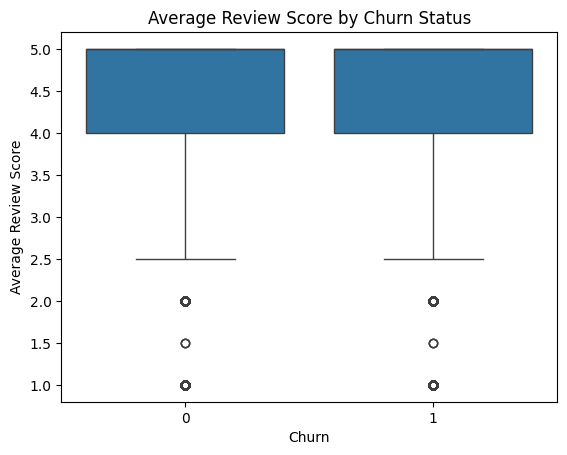

In [16]:
sns.boxplot(
    x='churn',
    y='avg_review_score',
    data=historical_data
)

plt.title('Average Review Score by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Average Review Score')

plt.show()

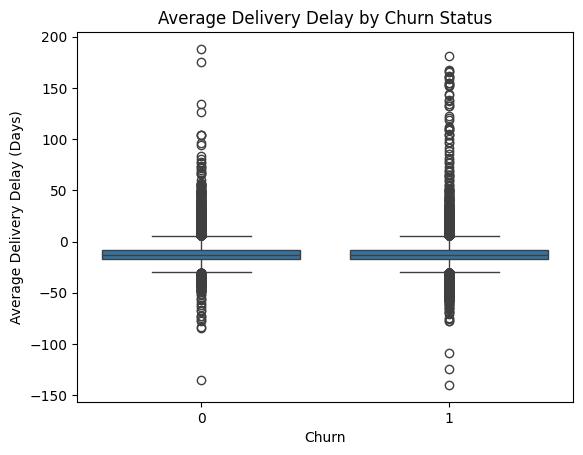

In [17]:
sns.boxplot(
    x='churn',
    y='avg_delivery_delay',
    data=historical_data
)

plt.title('Average Delivery Delay by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Average Delivery Delay (Days)')
plt.show()

In [18]:
historical_data.groupby('churn')['avg_delivery_delay'].mean()

,avg_delivery_delay
churn,
0,-11.365157
1,-12.405369


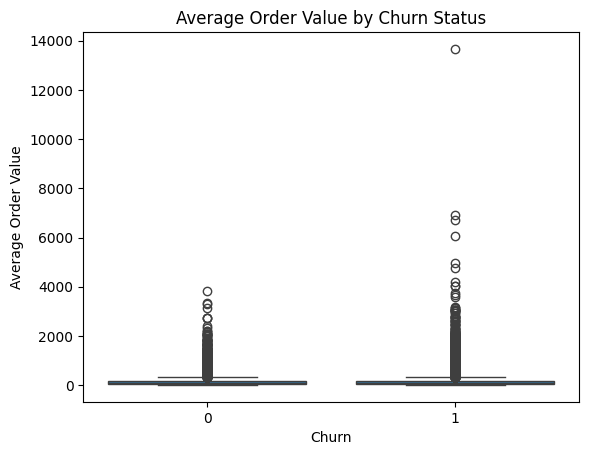

In [19]:
sns.boxplot(
    x='churn',
    y='avg_order_value',
    data=historical_data
)

plt.title('Average Order Value by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Average Order Value')

plt.show()

In [20]:
historical_data.groupby('churn')['avg_order_value'].mean()

,avg_order_value
churn,
0,150.866602
1,160.418802


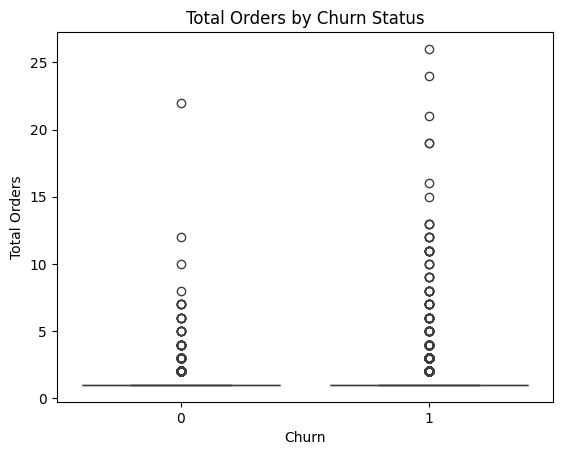

In [21]:
sns.boxplot(
    x='churn',
    y='total_orders',
    data=historical_data
)

plt.title('Total Orders by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Orders')

plt.show()

In [22]:
historical_data.groupby('churn')['total_orders'].mean()

,total_orders
churn,
0,1.045618
1,1.063512


In [23]:
correlation_data = historical_data[[
    'total_orders',
    'total_spent',
    'avg_order_value',
    'avg_delivery_delay',
    'avg_review_score',
    'late_delivery_ratio',
    'avg_installments',
    'avg_freight_value',
    'customer_tenure_days',
    'days_since_purchase',
    'churn'
]]

corr_matrix = correlation_data.corr()

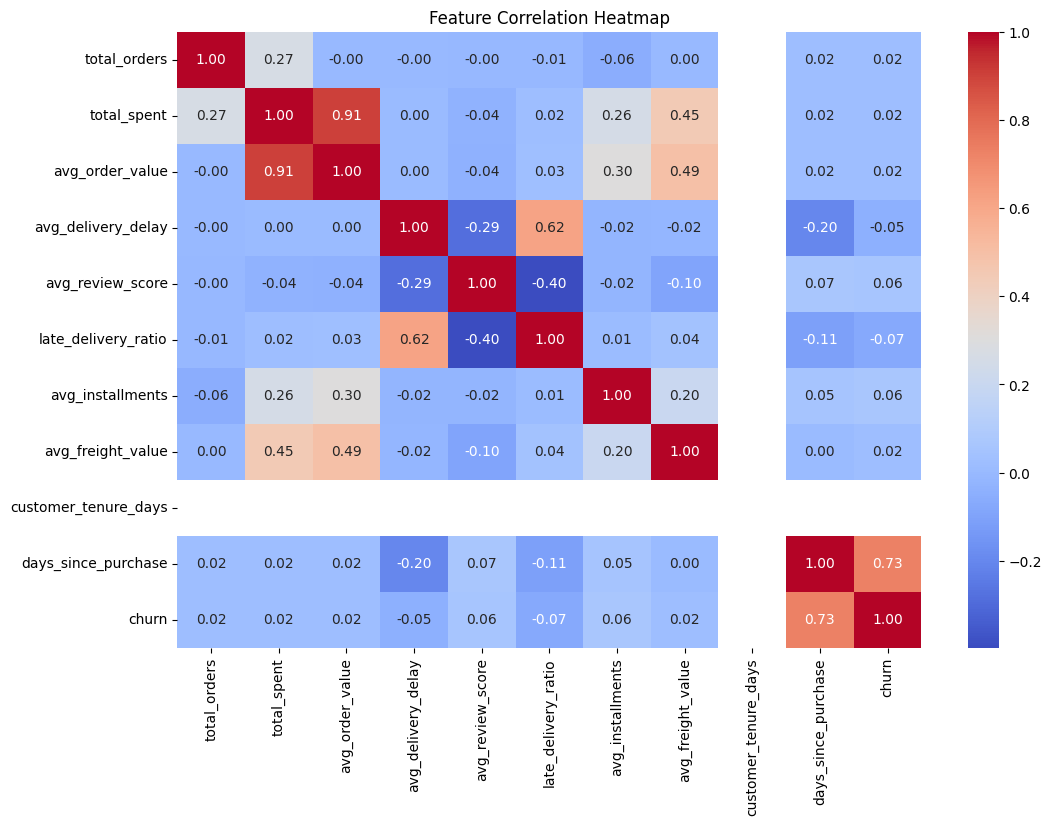

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

In [25]:
historical_data['churn'].value_counts()

,count
churn,
1,38182
0,19137


# Machine Learning Dataset Preparation

The historical dataset is prepared for predictive modeling using behavioral,
transactional, and operational customer features.

In [44]:
feature_columns = [

    'total_orders',
    'total_spent',
    'avg_order_value',
    'avg_delivery_delay',
    'avg_review_score',
    'late_delivery_ratio',
    'avg_installments',
    'avg_freight_value',
    'customer_tenure_days'
]

In [45]:
X = historical_data[feature_columns]

y = historical_data['churn']

In [46]:
X = X.fillna(X.median(numeric_only=True))

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
future_data['days_since_purchase'] = (
    historical_cutoff
    - future_data['last_order_date']
).dt.days

In [49]:
future_X = future_data[feature_columns]

future_X = future_X.fillna(
    future_X.median(numeric_only=True)
)

# Random Forest Churn Prediction

Random Forest is used to capture nonlinear relationships between customer
behavior and churn risk while providing feature importance insights.

In [50]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [51]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [52]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.62      0.09      0.15      3827
           1       0.68      0.97      0.80      7637

    accuracy                           0.68     11464
   macro avg       0.65      0.53      0.48     11464
weighted avg       0.66      0.68      0.58     11464



In [53]:
rf_auc = roc_auc_score(y_test, rf_prob)

print("ROC-AUC Score:", rf_auc)

ROC-AUC Score: 0.6355142586774556


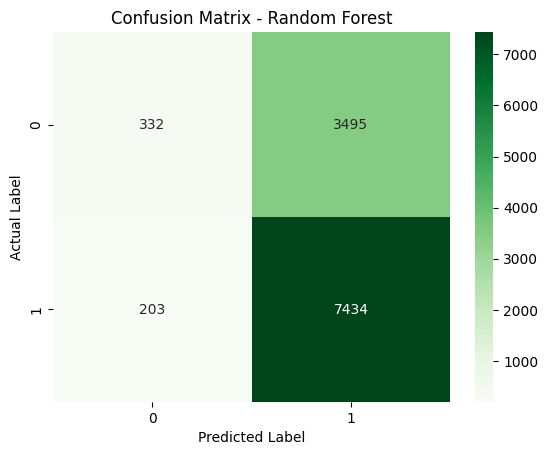

In [54]:
rf_cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

## Random Forest Model Evaluation

The Random Forest model demonstrates moderate predictive performance in identifying
customer churn behavior.

Key observations:
- The model achieves strong recall for churned customers
- Most at-risk customers are successfully identified
- Performance for identifying active customers is relatively weak
- The dataset imbalance influences prediction behavior toward the churn class

Evaluation Metrics:
- Accuracy: 68%
- ROC-AUC Score: 0.64

The model prioritizes churn detection, which can still provide business value
because identifying potentially lost customers is often more important than
perfectly classifying retained customers.

Overall, the results suggest that customer churn behavior contains meaningful
behavioral patterns, although additional features and advanced optimization may
further improve predictive performance.

In [55]:
feature_importance = pd.DataFrame({

    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
3,avg_delivery_delay,0.257276
7,avg_freight_value,0.249527
2,avg_order_value,0.161122
1,total_spent,0.155747
6,avg_installments,0.090537
4,avg_review_score,0.048889
5,late_delivery_ratio,0.025325
0,total_orders,0.011577
8,customer_tenure_days,0.000000


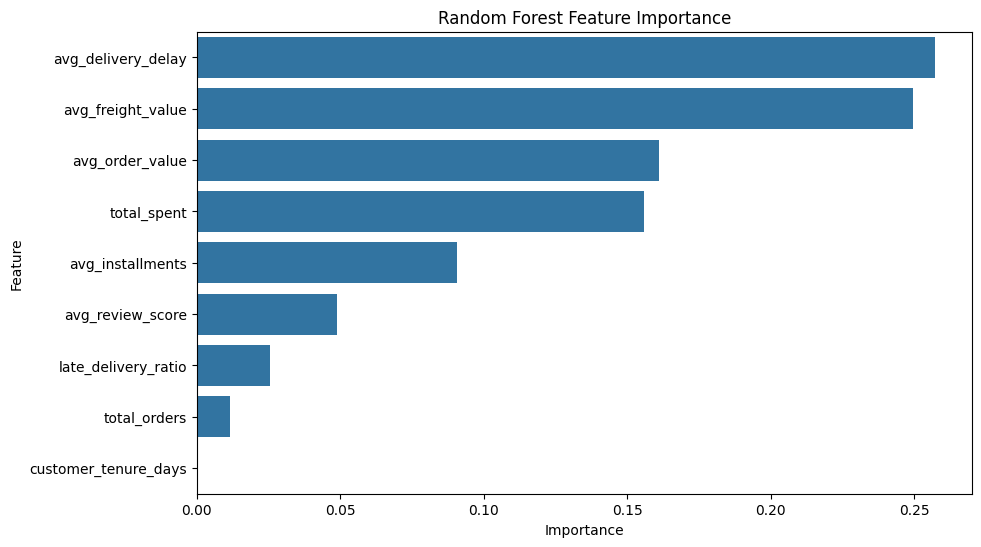

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Random Forest Feature Importance')

plt.show()

## Feature Importance Analysis

The Random Forest model identifies operational and transactional variables as
the strongest drivers influencing customer churn behavior.

Key findings:
- Delivery performance is the most influential churn predictor
- Freight cost has a major impact on customer retention
- Spending behavior contributes meaningfully to churn prediction
- Customer satisfaction variables show comparatively weaker influence
- Customer tenure has minimal predictive value in this dataset

The results suggest that churn in this marketplace is strongly associated with
logistics experience and order economics rather than long-term customer loyalty.

From a business perspective, improving delivery efficiency and optimizing freight
cost structures may help reduce customer attrition more effectively than relying
solely on customer satisfaction initiatives.

# Retention Strategy Simulation

The trained Random Forest model can be used to identify customers with elevated
churn risk and support proactive retention initiatives.

This section simulates how predictive churn analytics could help prioritize
high-risk customers for targeted intervention campaigns.

In [57]:
future_probabilities = rf_model.predict_proba(future_X)[:,1]

In [58]:
future_data['churn_probability'] = future_probabilities

In [59]:
high_risk_customers = future_data[
    future_data['churn_probability'] >= 0.70
]

In [60]:
print("High-Risk Customers:", len(high_risk_customers))

High-Risk Customers: 12040


In [61]:
high_risk_customers[[
    'customer_id',
    'total_spent',
    'avg_order_value',
    'avg_delivery_delay',
    'avg_freight_value',
    'churn_probability'
]].head()

,customer_id,total_spent,avg_order_value,avg_delivery_delay,avg_freight_value,churn_probability
9,000598caf2ef4117407665ac33275130,1255.71,1255.71,-17.0,148.71,0.756888
22,001051abfcfdbed9f87b4266213a5df1,195.60,65.20,-30.0,15.23,0.711707
27,0013cd8e350a7cc76873441e431dd5ee,92.60,92.60,-13.0,12.70,0.764883
34,0018c09f333634ca9c80d9ff46e43e9c,56.87,56.87,-13.0,13.88,0.735368
41,001f150aebb5d897f2059b0460c38449,125.97,125.97,-11.0,15.65,0.709693


## Retention Simulation Findings

The Random Forest model identified 12,040 customers with an estimated churn
probability greater than or equal to 70%.

Several high-risk customers also demonstrated relatively strong spending behavior,
indicating that valuable customers may still become vulnerable to churn when
operational experience declines.

The simulation results align closely with earlier feature importance analysis,
where delivery performance and freight costs emerged as the strongest predictors
of churn risk.

From a business perspective, predictive churn analytics can support:
- proactive customer retention campaigns
- logistics optimization initiatives
- targeted promotional strategies
- high-value customer protection efforts

The analysis demonstrates how machine learning can help prioritize customer
retention decisions using behavioral and operational data.

# Business Recommendations

Based on the analysis and predictive modeling results, the following actions may
help reduce customer churn:

- Improve delivery consistency and reduce operational delays
- Optimize freight pricing for higher-value customers
- Prioritize retention campaigns for customers with elevated churn probability
- Monitor logistics-related customer experience metrics more closely
- Develop loyalty initiatives focused on repeat purchasing behavior

The findings suggest that operational efficiency and delivery experience play a
critical role in long-term customer retention within the marketplace.

In [62]:
retention_success_rate = 0.15

estimated_retained_customers = int(
    len(high_risk_customers) * retention_success_rate
)

print("Estimated Retained Customers:",
      estimated_retained_customers)

Estimated Retained Customers: 1806


In [63]:
potential_revenue_protected = (
    high_risk_customers['total_spent'].mean()
    * estimated_retained_customers
)

print("Estimated Revenue Protection:",
      round(potential_revenue_protected,2))

Estimated Revenue Protection: 384007.21


## Retention Impact Simulation

To estimate potential business impact, a simulated retention campaign success
rate of 15% was applied to customers identified as high-risk by the Random
Forest model.

Simulation Results:
- High-Risk Customers Identified: 12,040
- Estimated Retained Customers: 1,806
- Estimated Revenue Protection: ~384K BRL

The simulation demonstrates how predictive churn analytics can support:
- proactive customer retention
- operational prioritization
- targeted intervention strategies
- revenue protection initiatives

Although the results represent estimated business scenarios rather than deployed
production outcomes, the analysis illustrates the practical value of machine
learning for customer retention decision-making.

# Conclusion

This project developed an end-to-end customer churn prediction framework using
behavioral, transactional, and logistics-related ecommerce data.

The analysis demonstrated that operational factors such as delivery performance
and freight costs were stronger churn drivers than traditional customer
satisfaction metrics alone.

Using Random Forest modeling, the project identified high-risk customers and
simulated retention strategies capable of supporting proactive business
decision-making.

The project combines:
- feature engineering
- exploratory analytics
- predictive machine learning
- churn risk segmentation
- business impact simulation

Overall, the analysis illustrates how data-driven retention strategies can help
ecommerce platforms better understand customer attrition and prioritize customer
retention efforts.

In [64]:
historical_data.to_csv(
    'customer_churn_modeling_dataset.csv',
    index=False
)

In [65]:
high_risk_customers.to_csv(
    'high_risk_customers.csv',
    index=False
)